# ***Import Libraries***

In [2]:
import pandas as pd
import numpy as np

**Load Dataset**

In [5]:
from google.colab import files

uploaded = files.upload()

Saving ApexPlanet_DataAnalytics_Dataset (1).xlsx to ApexPlanet_DataAnalytics_Dataset (1) (1).xlsx


In [7]:
import pandas as pd

df = pd.read_excel('ApexPlanet_DataAnalytics_Dataset (1).xlsx')

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


## ***Data Cleaning Code***





**Check Dataset Information**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


**Check Missing Values**

In [9]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,20
Gender,0
City,13
Product,0
Category,0
Quantity,0


**Check Duplicate Records**

In [10]:
df.duplicated().sum()

np.int64(0)

**Fill Missing Age Values**

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())

**Fill Missing City Values**

In [12]:
df['City'] = df['City'].fillna(df['City'].mode()[0])

**Verify Missing Values Removed**

In [13]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
City,0
Product,0
Category,0
Quantity,0


**Remove Duplicates**

In [14]:
df = df.drop_duplicates()

**Convert Date Format**

In [15]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [16]:
df['Sales_Per_Unit'] = df['Total_Sales'] / df['Quantity']

In [17]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Sales_Per_Unit
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2829.77
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,27906.16
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,37491.06
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,28541.36
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,14036.59


Dataset Shape

In [21]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 13)


In [22]:
print(df.columns)

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales', 'Sales_Per_Unit'],
      dtype='object')


In [23]:
df.describe()

,Order_Date,Age,Quantity,Unit_Price,Total_Sales,Sales_Per_Unit
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-07-03 11:19:40.800000,41.353000,5.435000,25486.783410,139399.439650,25486.783410
min,2025-01-01 00:00:00,18.000000,1.000000,145.780000,437.340000,145.780000
25%,2025-03-30 18:00:00,30.000000,3.000000,13895.722500,47066.632500,13895.722500
50%,2025-07-01 00:00:00,41.000000,5.000000,25398.740000,108594.025000,25398.740000
75%,2025-10-07 06:00:00,53.000000,8.000000,37512.382500,203722.882500,37512.382500
max,2026-01-01 00:00:00,65.000000,10.000000,49997.530000,493677.500000,49997.530000
std,NaN,13.683626,2.838632,14179.402361,114100.051546,14179.402361


In [24]:
df.dtypes

,0
Order_ID,object
Order_Date,datetime64[ns]
Customer_ID,object
Customer_Name,object
Age,float64
Gender,object
City,object
Product,object
Category,object
Quantity,int64


**Sales Analysis**

In [28]:
print("Total Sales:", df['Total_Sales'].sum())

Total Sales: 139399439.65


In [29]:
print("Average Sales:", df['Total_Sales'].mean())

Average Sales: 139399.43965000001


In [30]:
print("Maximum Sale:", df['Total_Sales'].max())

Maximum Sale: 493677.5


In [31]:
print("Minimum Sale:", df['Total_Sales'].min())

Minimum Sale: 437.34


**Gender Distribution**

In [32]:
df['Gender'].value_counts()

,count
Gender,
Male,511
Female,489


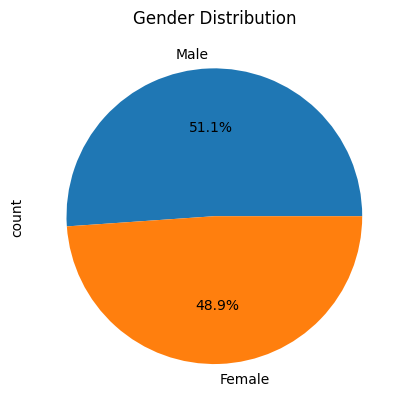

In [33]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

**Product Analysis**

In [34]:
df['Product'].value_counts().head(10)

,count
Product,
Mobile,184
Book,178
Laptop,170
Chair,159
Shoes,156
Rice,153


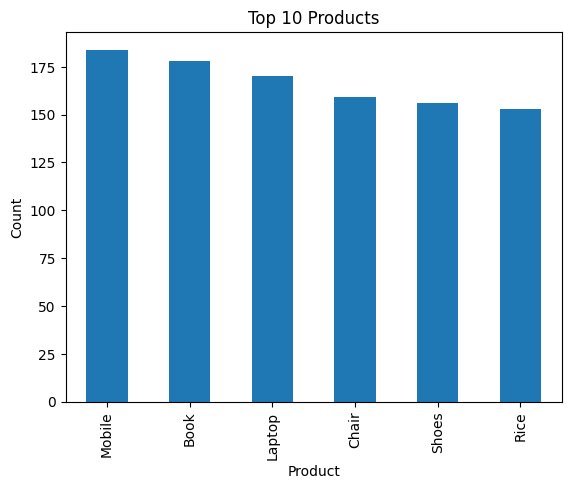

In [35]:
df['Product'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Products")
plt.xlabel("Product")
plt.ylabel("Count")
plt.show()

In [36]:
df['Category'].value_counts()

,count
Category,
Electronics,354
Education,178
Furniture,159
Fashion,156
Grocery,153


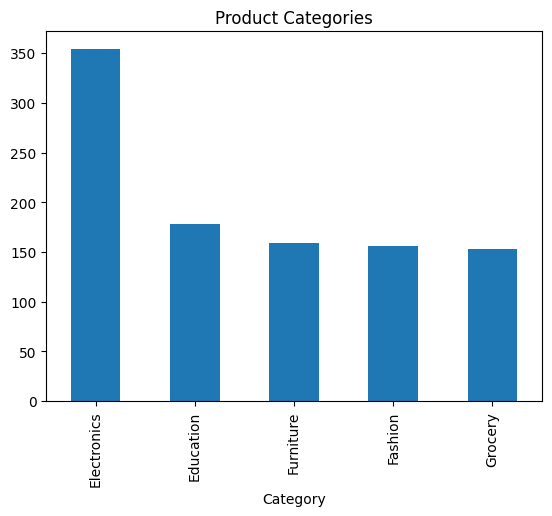

In [37]:
df['Category'].value_counts().plot(kind='bar')
plt.title("Product Categories")
plt.show()

In [38]:
df['City'].value_counts()

,count
City,
Patna,148
Kolkata,133
Mumbai,131
Hyderabad,125
Delhi,125
Bengaluru,122
Gaya,117
Pune,99


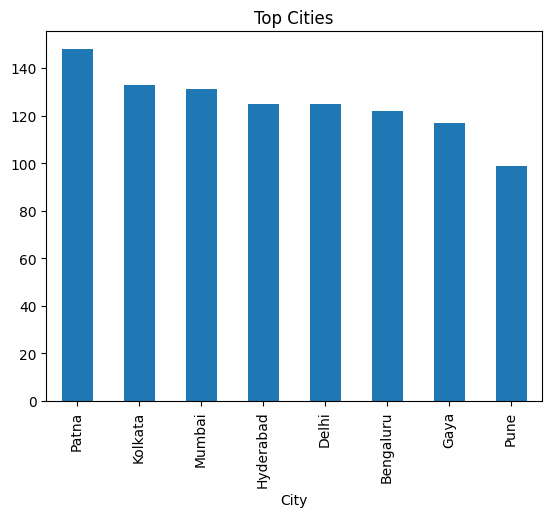

In [39]:
df['City'].value_counts().head(10).plot(kind='bar')
plt.title("Top Cities")
plt.show()

In [40]:
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.corr()

,Age,Quantity,Unit_Price,Total_Sales,Sales_Per_Unit
Age,1.000000,-0.027666,-0.011955,0.001294,-0.011955
Quantity,-0.027666,1.000000,0.021855,0.646641,0.021855
Unit_Price,-0.011955,0.021855,1.000000,0.686303,1.000000
Total_Sales,0.001294,0.646641,0.686303,1.000000,0.686303
Sales_Per_Unit,-0.011955,0.021855,1.000000,0.686303,1.000000


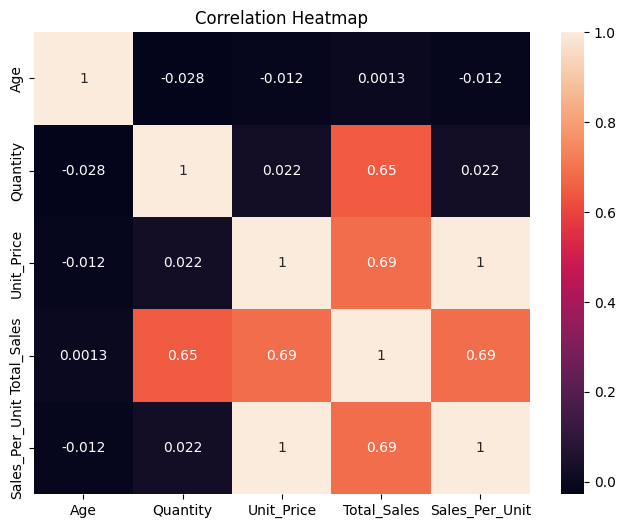

In [41]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

**Save Cleaned Dataset**

In [19]:
df.to_csv('cleaned_sales_dataset.csv', index=False)

In [43]:
from google.colab import files

files.download('cleaned_sales_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>